# FetchReachDense — TD3

Desarrollo de los capítulos 1–5. El capítulo 6 (informe técnico) se completará después. Ejecución local; Colab preparado pero pendiente de validación en un runtime real.

## Capítulo 1 — Librerías, bootstrap y variables transversales

Usar Python 3.12. La celda instala dependencias solo en Colab; en local preparar un entorno aislado siguiendo README. Los pins reflejan el probe local, no una ejecución Colab.

In [1]:
import os
import sys
import subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
DEPENDENCIES = {
    "gymnasium-robotics": "1.4.2", "gymnasium": "1.3.0", "mujoco": "3.2.7",
    "stable-baselines3": "2.9.0", "torch": "2.14.0", "numpy": "2.5.3",
    "pandas": "3.0.5", "matplotlib": "3.11.2", "pillow": "12.3.0",
    "imageio": "2.37.4", "imageio-ffmpeg": "0.6.0",
}
if IN_COLAB:
    os.environ["MUJOCO_GL"] = "egl"
    subprocess.check_call([sys.executable, "-m", "pip", "install", *[
        f"{name}=={version}" for name, version in DEPENDENCIES.items()
    ]])


In [2]:
import hashlib
import importlib.metadata
import json
import platform
import random
import time
from datetime import datetime, timezone

import gymnasium as gym
import gymnasium_robotics
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image, ImageDraw, ImageFont
from stable_baselines3 import TD3
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.noise import NormalActionNoise

gym.register_envs(gymnasium_robotics)
VERSIONS = {name: importlib.metadata.version(name) for name in DEPENDENCIES}
assert VERSIONS == DEPENDENCIES, (VERSIONS, DEPENDENCIES)
CONFIG = {
    "env_id": "FetchReachDense-v4", "algorithm": "TD3", "policy": "MultiInputPolicy",
    "profile": "smoke", "train_seed": 42, "device": "cpu", "torch_threads": 1,
    "baseline_seeds": list(range(101, 111)), "tuning_seeds": list(range(201, 206)),
    "final_eval_seeds": list(range(1001, 1011)), "reload_seeds": [401, 402],
    "video_seed": 301, "video_fps": 25, "video_size": 480,
    "success_definition": "success_final", "target_success": 0.90,
    "eval_freq": 5_000, "checkpoint_freq": 10_000, "rolling_window": 50,
    "profiles": {"smoke": {"timesteps": 5_000, "learning_starts": 500},
                 "full": {"timesteps": 100_000, "learning_starts": 1_000}},
    "td3": {"learning_rate": 1e-3, "gamma": 0.99, "tau": 0.005,
            "batch_size": 256, "buffer_size": 200_000, "train_freq": 1,
            "gradient_steps": 1, "policy_delay": 2, "target_policy_noise": 0.2,
            "target_noise_clip": 0.5},
    "action_noise_sigma": 0.1, "net_arch": [400, 300],
}
MODEL_FOLDER = "2-FetchReachDense"
PROJECT_ROOT = Path("/content") if IN_COLAB else Path.cwd().resolve()
MODEL_ROOT = PROJECT_ROOT if PROJECT_ROOT.name == MODEL_FOLDER else PROJECT_ROOT / MODEL_FOLDER
MODEL_DIR = MODEL_ROOT / "models"
VIDEO_DIR = MODEL_ROOT / "videos"
RESULTS_DIR = MODEL_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
RUNS_DIR = MODEL_ROOT / "runs"
SMOKE_DIR = PROJECT_ROOT / "tmp" / "fetch_smoke"
FINAL_MODEL = MODEL_DIR / "fetch_reach_td3.zip"
METADATA_PATH = FINAL_MODEL.with_suffix(".metadata.json")
for directory in (MODEL_DIR, VIDEO_DIR, RESULTS_DIR, FIGURES_DIR, RUNS_DIR):
    directory.mkdir(parents=True, exist_ok=True)
random.seed(CONFIG["train_seed"])
np.random.seed(CONFIG["train_seed"])
torch.manual_seed(CONFIG["train_seed"])
torch.set_num_threads(CONFIG["torch_threads"])
print(json.dumps({"versions": VERSIONS, "python": platform.python_version(),
                  "platform": platform.platform(), "machine": platform.machine(),
                  "device": CONFIG["device"], "cuda": torch.cuda.is_available(),
                  "mps": torch.backends.mps.is_available()}, indent=2))


AdroitHandRelocateDense-v1, AdroitHandHammerDense-v1, AdroitHandDoorDense-v1 environment's reward functions were updated in v1.2.1 without an environment version update. Therefore, use gymnasium-robotics==1.2.0 for v1 reproducibility or use v2 in gymnasium-robotics>=1.4.3. See https://github.com/Farama-Foundation/Gymnasium-Robotics/pull/220 for more details


{
  "versions": {
    "gymnasium-robotics": "1.4.2",
    "gymnasium": "1.3.0",
    "mujoco": "3.2.7",
    "stable-baselines3": "2.9.0",
    "torch": "2.14.0",
    "numpy": "2.5.3",
    "pandas": "3.0.5",
    "matplotlib": "3.11.2",
    "pillow": "12.3.0",
    "imageio": "2.37.4",
    "imageio-ffmpeg": "0.6.0"
  },
  "python": "3.12.13",
  "platform": "macOS-26.6.2-arm64-arm-64bit",
  "machine": "arm64",
  "device": "cpu",
  "cuda": false,
  "mps": true
}


{
  "environment_id": "FetchReachDense-v4",
  "entry_point": "gymnasium_robotics.envs.fetch.reach:MujocoFetchReachEnv",
  "max_episode_steps": 50,
  "action_space": "Box(-1.0, 1.0, (4,), float32)",
  "observation_space": "Dict('achieved_goal': Box(-inf, inf, (3,), float64), 'desired_goal': Box(-inf, inf, (3,), float64), 'observation': Box(-inf, inf, (10,), float64))",
  "n_substeps": 20,
  "timestep": 0.002,
  "dt": 0.04,
  "distance_threshold": 0.05,
  "target_range": 0.15,
  "block_gripper": true,
  "has_object": false,
  "reward_type": "dense",
  "versions": {
    "gymnasium-robotics": "1.4.2",
    "gymnasium": "1.3.0",
    "mujoco": "3.2.7",
    "stable-baselines3": "2.9.0",
    "torch": "2.14.0",
    "numpy": "2.5.3",
    "pandas": "3.0.5",
    "matplotlib": "3.11.2",
    "pillow": "12.3.0",
    "imageio": "2.37.4",
    "imageio-ffmpeg": "0.6.0"
  },
  "execution_target": "local",
  "python": "3.12.13",
  "gripper_invariance_pass": true,
  "reward_success_horizon_pass": true,
  "g

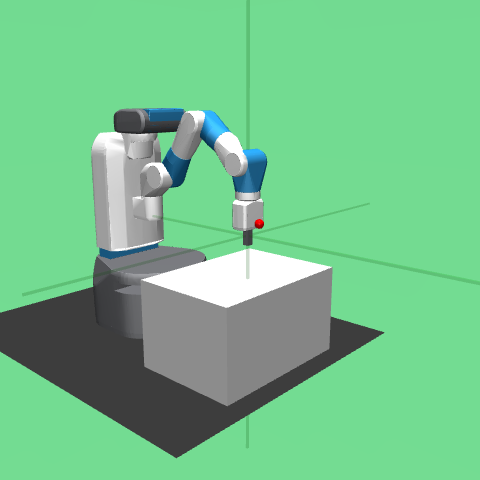

In [3]:
def make_env(seed, render=False):
    """Create the original environment and seed its spaces.

    Args:
        seed: Seed for environment and action/observation spaces.
        render: Whether to enable RGB rendering.

    Returns:
        A seeded Gymnasium environment with its original TimeLimit.
    """
    env = gym.make(CONFIG["env_id"], render_mode="rgb_array" if render else None,
                   width=CONFIG["video_size"], height=CONFIG["video_size"])
    env.action_space.seed(seed)
    env.observation_space.seed(seed)
    env.reset(seed=seed)
    return env


def write_json(path, value):
    """Write an inspectable JSON artifact.

    Args:
        path: Destination path.
        value: JSON-serializable data.
    """
    Path(path).write_text(json.dumps(value, indent=2, allow_nan=False) + "\n")


probe = make_env(CONFIG["train_seed"], render=True)
try:
    obs, _ = probe.reset(seed=CONFIG["train_seed"])
    assert probe.action_space.shape == (4,)
    assert {key: value.shape for key, value in obs.items()} == {
        "observation": (10,), "achieved_goal": (3,), "desired_goal": (3,)}
    raw = probe.unwrapped
    assert raw.n_substeps == 20 and np.isclose(raw.model.opt.timestep, 0.002)
    assert np.isclose(raw.dt, 0.04) and probe.spec.max_episode_steps == 50
    assert np.isclose(raw.distance_threshold, 0.05) and np.isclose(raw.target_range, 0.15)
    assert raw.block_gripper and not raw.has_object and raw.reward_type == "dense"
    goals = []
    for seed in CONFIG["baseline_seeds"]:
        obs, _ = probe.reset(seed=seed)
        goals.append(obs["desired_goal"].copy())
        assert np.all(np.abs(obs["desired_goal"] - raw.initial_gripper_xpos) <= raw.target_range)
    assert len(np.unique(goals, axis=0)) == len(goals)
    probe.reset(seed=CONFIG["train_seed"])
    for step in range(1, probe.spec.max_episode_steps + 1):
        obs, reward, terminated, truncated, info = probe.step(probe.action_space.sample())
        distance = np.linalg.norm(obs["achieved_goal"] - obs["desired_goal"])
        assert np.isfinite(reward) and np.isclose(reward, -distance, atol=1e-6)
        assert bool(info["is_success"]) == bool(distance < raw.distance_threshold)
        assert not terminated and truncated == (step == probe.spec.max_episode_steps)
    # Compare the full state trajectory with opposite gripper commands.
    trajectories = []
    for gripper in (-1.0, 1.0):
        probe.reset(seed=CONFIG["train_seed"])
        trajectory = []
        for _ in range(10):
            obs, *_ = probe.step(np.array([0.1, -0.1, 0.1, gripper], dtype=np.float32))
            trajectory.append(obs["observation"].copy())
        trajectories.append(trajectory)
    assert np.allclose(*trajectories, atol=1e-12)
    frame = probe.render()
    assert frame.shape == (CONFIG["video_size"], CONFIG["video_size"], 3)
    contract = {"environment_id": probe.spec.id, "entry_point": probe.spec.entry_point,
                "max_episode_steps": probe.spec.max_episode_steps,
                "action_space": str(probe.action_space), "observation_space": str(probe.observation_space),
                "n_substeps": raw.n_substeps, "timestep": raw.model.opt.timestep, "dt": raw.dt,
                "distance_threshold": raw.distance_threshold, "target_range": raw.target_range,
                "block_gripper": raw.block_gripper, "has_object": raw.has_object,
                "reward_type": raw.reward_type, "versions": VERSIONS,
                "execution_target": "colab" if IN_COLAB else "local",
                "python": platform.python_version(), "gripper_invariance_pass": True,
                "reward_success_horizon_pass": True, "goal_sampling_pass": True,
                "render_shape": list(frame.shape)}
    write_json(RESULTS_DIR / "runtime_contract.json", contract)
    print(json.dumps(contract, indent=2))
    display(Image.fromarray(frame))
finally:
    probe.close()


## Capítulo 2 — Definición del agente

El brazo debe alcanzar y mantener el efector cerca del objetivo. El episodio continúa hasta 50 pasos, incluso si alcanza la meta. El éxito principal es **success_final**: distancia estrictamente menor que 0.05 m al último paso. `success_any` y `success_fraction` permiten distinguir alcanzar de permanecer. El retorno suma `-distance` durante todo el episodio.

La evaluación usa seeds distintas del entrenamiento; las seeds finales quedan reservadas hasta cerrar la selección del modelo. La referencia inicial es una política uniforme en el action space original.

In [4]:
def evaluate_policy(model, seeds):
    """Evaluate complete episodes without learning or exploration noise.

    Args:
        model: Predict-compatible policy, or None for uniform random actions.
        seeds: Explicit evaluation seeds, separate from training.

    Returns:
        DataFrame with returns, success and geometric diagnostics per episode.
    """
    rows = []
    env = make_env(seeds[0])
    try:
        for seed in seeds:
            obs, _ = env.reset(seed=seed)
            env.action_space.seed(seed)
            rewards, distances, successes = [], [], []
            terminated = truncated = False
            while not (terminated or truncated):
                action = env.action_space.sample() if model is None else model.predict(obs, deterministic=True)[0]
                assert env.action_space.contains(np.asarray(action, dtype=np.float32))
                obs, reward, terminated, truncated, info = env.step(action)
                rewards.append(float(reward))
                distances.append(float(np.linalg.norm(obs["achieved_goal"] - obs["desired_goal"])))
                successes.append(bool(info["is_success"]))
            rows.append({"seed": seed, "episode_return": sum(rewards), "episode_length": len(rewards),
                         "success_any": any(successes), "success_final": successes[-1],
                         "success_fraction": float(np.mean(successes)),
                         "time_to_first_success": successes.index(True) + 1 if any(successes) else None,
                         "min_distance": min(distances), "final_distance": distances[-1]})
    finally:
        env.close()
    return pd.DataFrame(rows).astype({"time_to_first_success": "Float64"})


assert not set(CONFIG["baseline_seeds"]) & set(CONFIG["tuning_seeds"] + CONFIG["final_eval_seeds"])
random_df = evaluate_policy(None, CONFIG["baseline_seeds"])
assert len(random_df) == 10 and (random_df["episode_length"] == 50).all()
assert {"seed", "episode_return", "episode_length", "success_any", "success_final",
        "success_fraction", "min_distance", "final_distance"}.issubset(random_df.columns)
assert random_df["episode_return"].notna().all()
assert random_df["success_fraction"].between(0, 1).all()
repeat = evaluate_policy(None, CONFIG["baseline_seeds"][:1])
pd.testing.assert_frame_equal(random_df.iloc[:1].reset_index(drop=True), repeat)
repro_env = make_env(CONFIG["baseline_seeds"][0])
try:
    a, _ = repro_env.reset(seed=CONFIG["baseline_seeds"][0])
    b, _ = repro_env.reset(seed=CONFIG["baseline_seeds"][0])
    c, _ = repro_env.reset(seed=CONFIG["baseline_seeds"][1])
    np.testing.assert_allclose(a["desired_goal"], b["desired_goal"])
    assert not np.allclose(a["desired_goal"], c["desired_goal"])
finally:
    repro_env.close()
random_df.to_csv(RESULTS_DIR / "random_baseline_initial.csv", index=False)
display(random_df)
print(random_df[["episode_return", "success_final", "success_fraction", "final_distance"]].mean())


,seed,episode_return,episode_length,success_any,success_final,success_fraction,time_to_first_success,min_distance,final_distance
0,101,-5.876819,50,False,False,0.00,<NA>,0.053993,0.230958
1,102,-14.822783,50,False,False,0.00,<NA>,0.106646,0.315441
2,103,-6.270923,50,False,False,0.00,<NA>,0.077838,0.133930
3,104,-4.927047,50,True,False,0.10,14.0,0.040108,0.174282
4,105,-16.273743,50,False,False,0.00,<NA>,0.155186,0.457558
5,106,-9.113999,50,False,False,0.00,<NA>,0.092094,0.185913
6,107,-8.272868,50,True,False,0.04,1.0,0.035941,0.195099
7,108,-12.009860,50,False,False,0.00,<NA>,0.128763,0.375144
8,109,-11.389331,50,False,False,0.00,<NA>,0.087117,0.315874
9,110,-13.132645,50,False,False,0.00,<NA>,0.115021,0.304113


episode_return     -10.209002
success_final        0.000000
success_fraction     0.014000
final_distance       0.268831
dtype: float64


### Agente baseline

TD3 usa dos críticos, actualizaciones retrasadas del actor y suavizado de la política objetivo para controlar el sesgo de valor. `MultiInputPolicy` concatena internamente los componentes del Dict, sin modificar el GoalEnv. Actor y críticos usan MLP `[400, 300]`, ReLU. El ruido gaussiano de exploración tiene sigma 0.1 en las cuatro acciones y se desactiva en evaluación determinista.

CPU, un thread, reduce overhead para este MLP. TD3 complementa SAC en Adroit y la hipótesis PPO para HandReach. Selección: success_final primero, después retorno medio, permanencia, variabilidad y tiempo. Fuente: [SB3 TD3](https://stable-baselines3.readthedocs.io/en/master/modules/td3.html); se verificó también el código instalado 2.9.0.

In [5]:
def build_model(train_env, profile):
    """Build the configured TD3 baseline for one execution profile.

    Args:
        train_env: Original Dict environment, optionally wrapped by Monitor.
        profile: Either smoke or full.

    Returns:
        A fresh TD3 model with explicit exploration noise.
    """
    assert profile in CONFIG["profiles"]
    return TD3(CONFIG["policy"], train_env, **CONFIG["td3"],
               learning_starts=CONFIG["profiles"][profile]["learning_starts"],
               action_noise=NormalActionNoise(np.zeros(train_env.action_space.shape),
                    CONFIG["action_noise_sigma"] * np.ones(train_env.action_space.shape)),
               policy_kwargs={"net_arch": CONFIG["net_arch"], "activation_fn": torch.nn.ReLU},
               seed=CONFIG["train_seed"], device=CONFIG["device"], verbose=0)


assert set(CONFIG["profiles"]) == {"smoke", "full"}
assert not set(CONFIG["tuning_seeds"]) & set(CONFIG["final_eval_seeds"])
assert CONFIG["train_seed"] not in CONFIG["tuning_seeds"] + CONFIG["final_eval_seeds"]
train_env = make_env(CONFIG["train_seed"])
try:
    obs, _ = train_env.reset(seed=CONFIG["train_seed"])
    model = build_model(train_env, profile="smoke")
    action, _ = model.predict(obs, deterministic=True)
    assert action.shape == (4,)
    assert train_env.action_space.contains(action.astype(train_env.action_space.dtype))
    print(model.policy)
    print(model.action_noise)
    print(json.dumps(CONFIG, indent=2))
finally:
    train_env.close()
    del model


MultiInputPolicy(
  (actor): Actor(
    (features_extractor): CombinedExtractor(
      (extractors): ModuleDict(
        (achieved_goal): Flatten(start_dim=1, end_dim=-1)
        (desired_goal): Flatten(start_dim=1, end_dim=-1)
        (observation): Flatten(start_dim=1, end_dim=-1)
      )
    )
    (mu): Sequential(
      (0): Linear(in_features=16, out_features=400, bias=True)
      (1): ReLU()
      (2): Linear(in_features=400, out_features=300, bias=True)
      (3): ReLU()
      (4): Linear(in_features=300, out_features=4, bias=True)
      (5): Tanh()
    )
  )
  (actor_target): Actor(
    (features_extractor): CombinedExtractor(
      (extractors): ModuleDict(
        (achieved_goal): Flatten(start_dim=1, end_dim=-1)
        (desired_goal): Flatten(start_dim=1, end_dim=-1)
        (observation): Flatten(start_dim=1, end_dim=-1)
      )
    )
    (mu): Sequential(
      (0): Linear(in_features=16, out_features=400, bias=True)
      (1): ReLU()
      (2): Linear(in_features=400, ou

## Capítulo 3 — Construcción y ejecución del entrenamiento

Primero se ejecuta un smoke de 5.000 pasos sin render. Monitor registra retorno, duración y éxito del último paso. Se cierra el entorno de entrenamiento antes de recargar el checkpoint en un entorno independiente; se comparan pesos y resultados deterministas sin actualizaciones. Los temporales no son el modelo de entrega.

In [6]:
class TrainingEvidence(BaseCallback):
    """Record independent tuning evaluations and recoverable checkpoints.

    Args:
        run_dir: Directory dedicated to this training run.
    """
    def __init__(self, run_dir):
        super().__init__()
        self.run_dir = run_dir
        self.checkpoint_dir = run_dir / "checkpoints"
        self.checkpoint_dir.mkdir(parents=True, exist_ok=True)
        self.rows = []

    def _on_step(self):
        """Persist bounded evidence at configured step intervals."""
        if self.num_timesteps % CONFIG["eval_freq"] == 0:
            evaluation = evaluate_policy(self.model, CONFIG["tuning_seeds"])
            evaluation["timesteps"] = self.num_timesteps
            self.rows.extend(evaluation.to_dict("records"))
            pd.DataFrame(self.rows).to_csv(self.run_dir / "tuning.csv", index=False)
        if self.num_timesteps % CONFIG["checkpoint_freq"] == 0:
            self.model.save(self.checkpoint_dir / f"checkpoint_{self.num_timesteps}.zip")
            self.model.save_replay_buffer(self.run_dir / "latest_replay.pkl")
        return True


def train_model(profile):
    """Train one run through the shared smoke/full path.

    Args:
        profile: Configured smoke or full budget.

    Returns:
        Run directory and metadata; saves candidate, logs and checkpoints.
    """
    run_id = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ") + "_" + profile
    run_dir = RUNS_DIR / run_id
    run_dir.mkdir(parents=True)
    train_env = Monitor(make_env(CONFIG["train_seed"]), str(run_dir / "training.monitor.csv"),
                        info_keywords=("is_success",))
    model = build_model(train_env, profile)
    callback = TrainingEvidence(run_dir)
    candidate_path = run_dir / "candidate.zip"
    initial = {key: value.clone() for key, value in model.policy.state_dict().items()}
    started_at = datetime.now(timezone.utc).isoformat()
    started = time.perf_counter()
    try:
        model.learn(total_timesteps=CONFIG["profiles"][profile]["timesteps"], callback=callback)
        training_time_seconds = time.perf_counter() - started
        assert model.num_timesteps == CONFIG["profiles"][profile]["timesteps"]
        assert model._n_updates > 0
        assert any(not torch.equal(value, initial[key]) for key, value in model.policy.state_dict().items())
        assert all(torch.isfinite(value).all() for value in model.policy.state_dict().values())
        model.save(candidate_path)
        model.save(callback.checkpoint_dir / f"checkpoint_{model.num_timesteps}.zip")
        model.save_replay_buffer(run_dir / "latest_replay.pkl")
        original_eval = evaluate_policy(model, CONFIG["reload_seeds"])
        metadata = {"run_id": run_id, "profile": profile, "environment_id": CONFIG["env_id"],
                    "algorithm": CONFIG["algorithm"], "policy": CONFIG["policy"],
                    "seed": CONFIG["train_seed"], "total_timesteps": model.num_timesteps,
                    "gradient_updates": model._n_updates, "configuration": CONFIG,
                    "versions": VERSIONS, "python": platform.python_version(),
                    "hardware": platform.platform() + " " + platform.machine(),
                    "device": CONFIG["device"], "started_at": started_at,
                    "ended_at": datetime.now(timezone.utc).isoformat(),
                    "training_seconds": training_time_seconds,
                    "candidate_sha256": hashlib.sha256(candidate_path.read_bytes()).hexdigest()}
        write_json(run_dir / "run.json", metadata)
    finally:
        train_env.close()
    del model, initial
    eval_env = make_env(CONFIG["reload_seeds"][0])
    try:
        reloaded = TD3.load(candidate_path, env=eval_env, device=CONFIG["device"])
        before = {key: value.clone() for key, value in reloaded.policy.state_dict().items()}
        updates = reloaded._n_updates
        evaluation = evaluate_policy(reloaded, CONFIG["reload_seeds"])
        pd.testing.assert_frame_equal(evaluation, original_eval)
        assert updates == reloaded._n_updates
        assert all(torch.equal(value, before[key]) for key, value in reloaded.policy.state_dict().items())
        assert np.isfinite(evaluation[["episode_return", "final_distance"]]).all().all()
        evaluation.to_csv(run_dir / "reload_evaluation.csv", index=False)
        log = pd.read_csv(run_dir / "training.monitor.csv", comment="#")
        assert len(log) * 50 == metadata["total_timesteps"]
        assert np.isfinite(log[["r", "l", "t", "is_success"]]).all().all()
    finally:
        eval_env.close()
    assert callback.checkpoint_dir.exists() and training_time_seconds > 0
    print(json.dumps(metadata, indent=2))
    display(evaluation)
    return run_dir, metadata


def record_video(model, output_path, title, source):
    """Record one deterministic episode with visible return and success.

    Args:
        model: Loaded prediction-only policy or TD3 checkpoint.
        output_path: MP4 destination.
        title: Human-readable video title.
        source: Source checkpoint metadata for provenance.

    Returns:
        Video metadata including frame count, source and episode metrics.
    """
    env = make_env(CONFIG["video_seed"], render=True)
    total_reward = 0.0
    frames = 0
    try:
        obs, _ = env.reset(seed=CONFIG["video_seed"])
        with imageio.get_writer(output_path, fps=CONFIG["video_fps"], codec="libx264",
                                macro_block_size=16) as writer:
            terminated = truncated = False
            while not (terminated or truncated):
                action, _ = model.predict(obs, deterministic=True)
                obs, reward, terminated, truncated, info = env.step(action)
                total_reward += float(reward)
                distance = float(np.linalg.norm(obs["achieved_goal"] - obs["desired_goal"]))
                frame = Image.fromarray(env.render())
                draw = ImageDraw.Draw(frame)
                draw.rectangle((0, 0, frame.width, 88), fill=(18, 24, 38))
                font = ImageFont.load_default(size=19)
                draw.text((12, 8), title, fill="white", font=font)
                draw.text((12, 34), f"Reward: {total_reward:.3f} | Step: {frames+1}", fill="white", font=font)
                draw.text((12, 60), f"Distance: {distance:.3f} m | Success: {int(info['is_success'])}", fill="white", font=font)
                writer.append_data(np.asarray(frame))
                frames += 1
        assert frames == env.spec.max_episode_steps
    finally:
        env.close()
    result = {"title": title, "source": source, "seed": CONFIG["video_seed"],
              "frames": frames, "fps": CONFIG["video_fps"], "duration_seconds": frames / CONFIG["video_fps"],
              "episode_return": total_reward, "final_distance": distance,
              "success_final": bool(info["is_success"]), "deterministic": True,
              "video_sha256": hashlib.sha256(Path(output_path).read_bytes()).hexdigest()}
    write_json(Path(output_path).with_suffix(".json"), result)
    return result


{
  "run_id": "20260912T004952796332Z_smoke",
  "profile": "smoke",
  "environment_id": "FetchReachDense-v4",
  "algorithm": "TD3",
  "policy": "MultiInputPolicy",
  "seed": 42,
  "total_timesteps": 5000,
  "gradient_updates": 4500,
  "configuration": {
    "env_id": "FetchReachDense-v4",
    "algorithm": "TD3",
    "policy": "MultiInputPolicy",
    "profile": "smoke",
    "train_seed": 42,
    "device": "cpu",
    "torch_threads": 1,
    "baseline_seeds": [
      101,
      102,
      103,
      104,
      105,
      106,
      107,
      108,
      109,
      110
    ],
    "tuning_seeds": [
      201,
      202,
      203,
      204,
      205
    ],
    "final_eval_seeds": [
      1001,
      1002,
      1003,
      1004,
      1005,
      1006,
      1007,
      1008,
      1009,
      1010
    ],
    "reload_seeds": [
      401,
      402
    ],
    "video_seed": 301,
    "video_fps": 25,
    "video_size": 480,
    "success_definition": "success_final",
    "target_success": 0.9,

,seed,episode_return,episode_length,success_any,success_final,success_fraction,time_to_first_success,min_distance,final_distance
0,401,-4.913719,50,False,False,0.00,<NA>,0.096491,0.096504
1,402,-1.654497,50,True,True,0.92,5.0,0.027661,0.028051


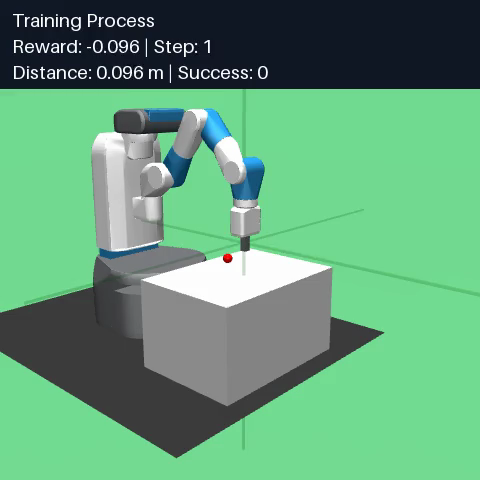

Smoke gates passed: training, checkpoint, reload, evaluation and MP4.


In [7]:
smoke_run_dir, smoke_metadata = train_model("smoke")
smoke_candidate = smoke_run_dir / "candidate.zip"
smoke_video = smoke_run_dir / "smoke.mp4"
smoke_policy = TD3.load(smoke_candidate, device=CONFIG["device"])
smoke_video_metadata = record_video(smoke_policy, smoke_video, "Training Process",
                                   {"run_id": smoke_metadata["run_id"], "timesteps": smoke_metadata["total_timesteps"]})
reader = imageio.get_reader(smoke_video)
try:
    assert reader.count_frames() == 50
    assert reader.get_meta_data()["fps"] == CONFIG["video_fps"]
    display(Image.fromarray(reader.get_data(0)))
finally:
    reader.close()
del smoke_policy
SMOKE_PASSED = True
print("Smoke gates passed: training, checkpoint, reload, evaluation and MP4.")


## Capítulo 4 — Métricas y gráficas

Pendiente de la tarea correspondiente; no ejecutar entrenamiento completo aún.

## Capítulo 5 — Videos

Pendiente de la tarea correspondiente; no ejecutar entrenamiento completo aún.